## Set up

In [1]:
#importing packages
#packages for directory and file handling
import os
import glob

#packages for flow cytometry data handling
import FlowCal

#packages for data handling
import pandas as pd
import numpy as np
from pandas.api.types import CategoricalDtype
from scipy.stats import gaussian_kde

#packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, Normalize

In [2]:
#fontsize =7
def custom_theme_7pt():
    sns.set_style("whitegrid")
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.3
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['ytick.major.width'] = 0.3
    plt.rcParams['xtick.minor.size'] = 2
    plt.rcParams['xtick.minor.width'] = 0.2
    plt.rcParams['ytick.minor.size'] = 2
    plt.rcParams['ytick.minor.width'] = 0.2
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['font.size'] = 7
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['legend.fontsize'] = 7
    plt.rcParams['legend.title_fontsize'] = 7
    plt.rcParams['axes.labelsize'] = 7
    plt.rcParams['axes.titlesize'] = 7
    plt.rcParams['axes.grid'] = False

    #additionas to theme
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42 


#fontsize = 6
def custom_theme_6pt():
    sns.set_style("whitegrid")
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.3
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['ytick.major.width'] = 0.3
    plt.rcParams['xtick.minor.size'] = 2
    plt.rcParams['xtick.minor.width'] = 0.2
    plt.rcParams['ytick.minor.size'] = 2
    plt.rcParams['ytick.minor.width'] = 0.2
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['font.size'] = 6
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['legend.fontsize'] = 6
    plt.rcParams['legend.title_fontsize'] = 6
    plt.rcParams['axes.labelsize'] = 6
    plt.rcParams['axes.titlesize'] = 6
    plt.rcParams['axes.grid'] = False

    #additions to theme
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42


#fontsize =5
def custom_theme_5pt():
    sns.set_style("whitegrid")
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.3
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['ytick.major.width'] = 0.3
    plt.rcParams['xtick.minor.size'] = 2
    plt.rcParams['xtick.minor.width'] = 0.2
    plt.rcParams['ytick.minor.size'] = 2
    plt.rcParams['ytick.minor.width'] = 0.2
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['font.size'] = 5
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['legend.fontsize'] = 5
    plt.rcParams['legend.title_fontsize'] = 5
    plt.rcParams['axes.labelsize'] = 5
    plt.rcParams['axes.titlesize'] = 5
    plt.rcParams['axes.grid'] = False

    #additions to theme
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42

## Import 

In [3]:
#get all subdirs in fcs_files (corresponding to experiments)
os.getcwd()
files = glob.glob('fcs_files/AS 221107 H9 regional spec/*fcs')
sorted_files = sorted(files)
sorted_files[:5]

#import all files in the dictionary and save as new dictionary
imported_files = {}
for filename in sorted_files:
    fcs_data = FlowCal.io.FCSData(filename)
    imported_files[filename] = fcs_data

#check the shape of the imported files
keys_shapes = []
for key, value in imported_files.items():
    keys_shapes.append(f"{key}: {value.shape}")

#make the output more readable (uncomment to inspect)

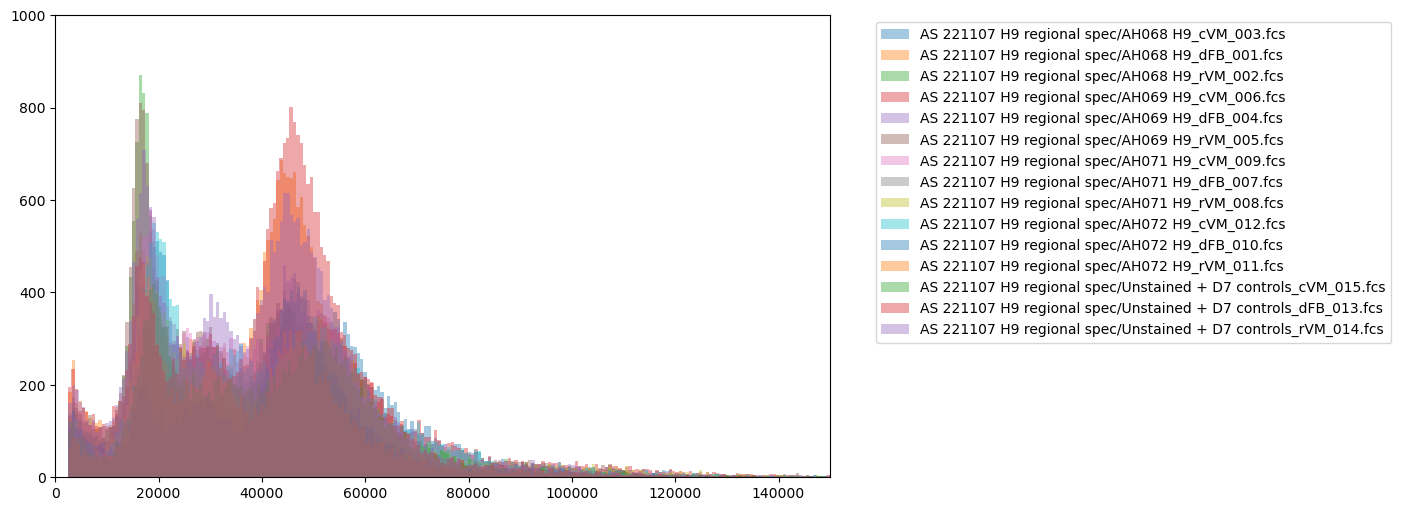

In [4]:
plt.figure(figsize=(10, 6)) # make the figure wider
for i, (filename, file) in enumerate(imported_files.items()):
    folder_name = os.path.basename(os.path.dirname(filename))  # Extract the folder name
    plt.hist(file[:, 'FSC-A'], bins=400, alpha=0.4, 
                label=f'{folder_name}/{os.path.basename(filename)}')

plt.ylim(0, 1000)
plt.xlim(0, 150000)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Plot with density scatter

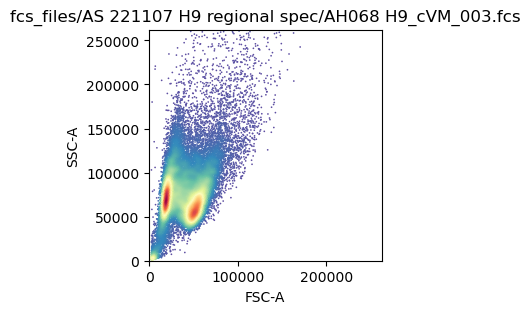

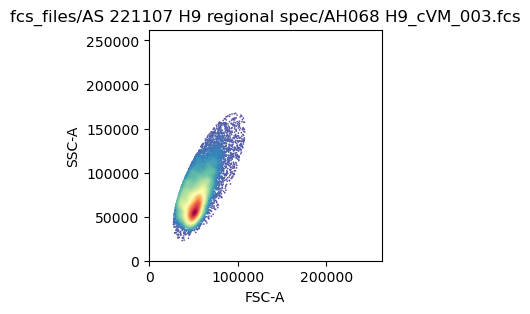

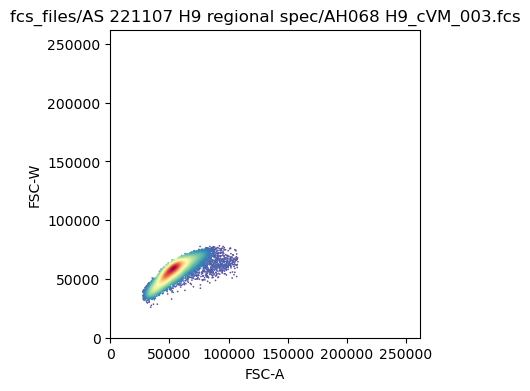

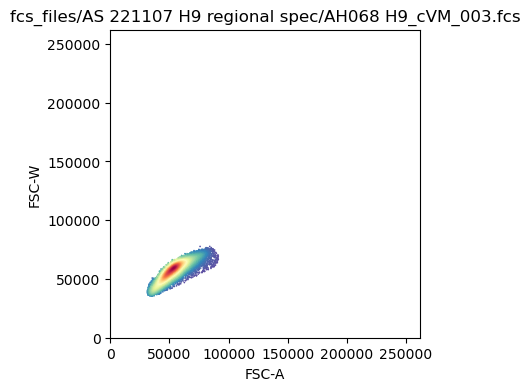

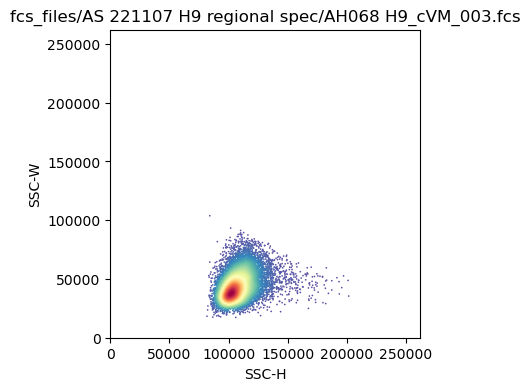

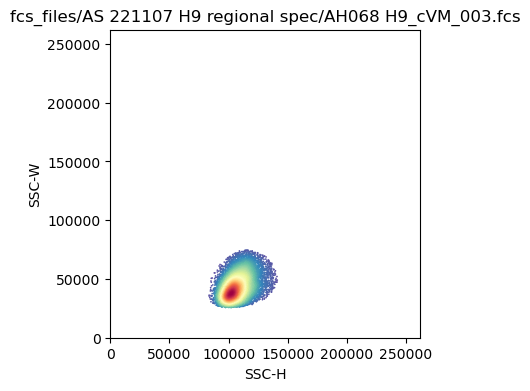

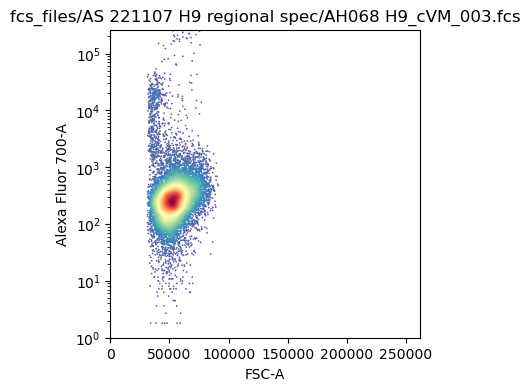

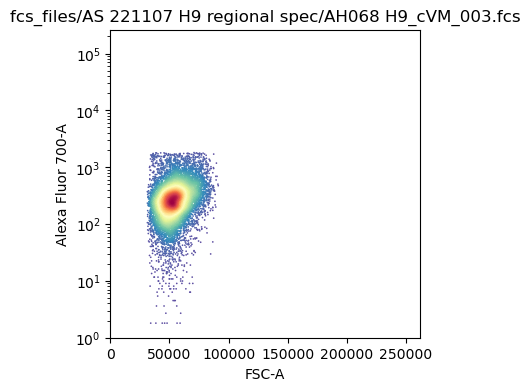

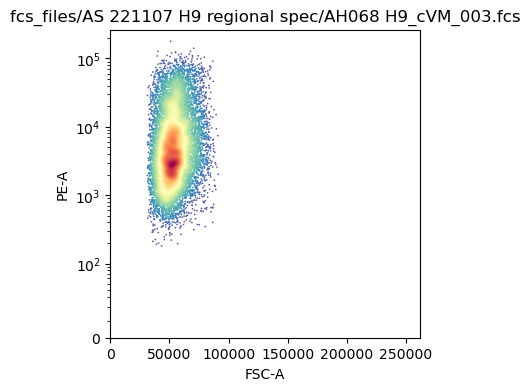

Number of events in gated sample: 11424


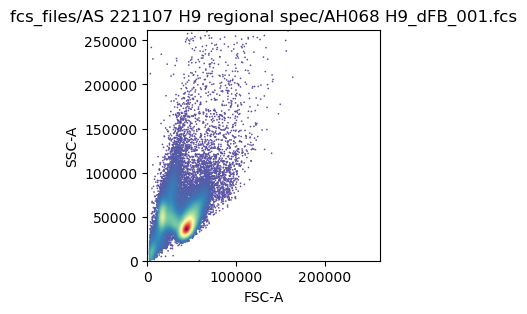

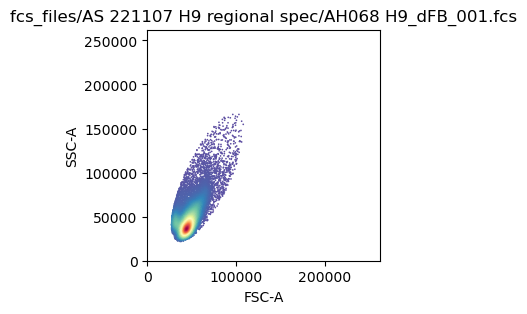

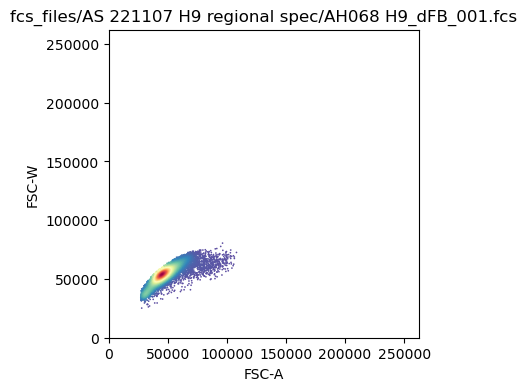

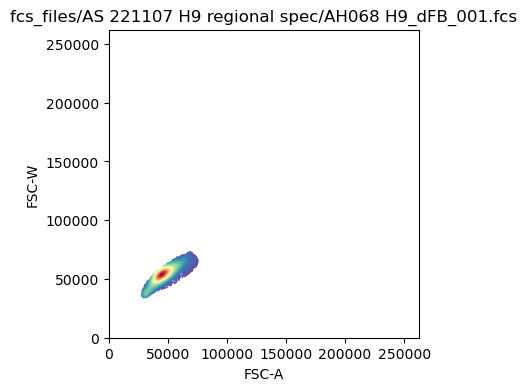

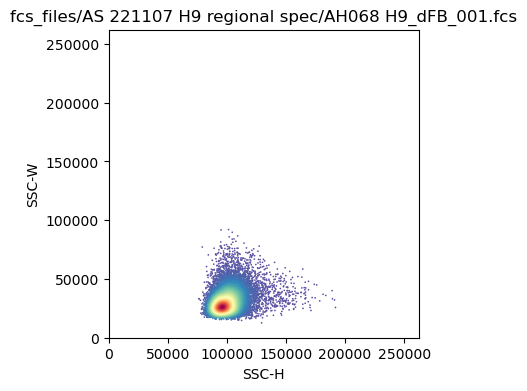

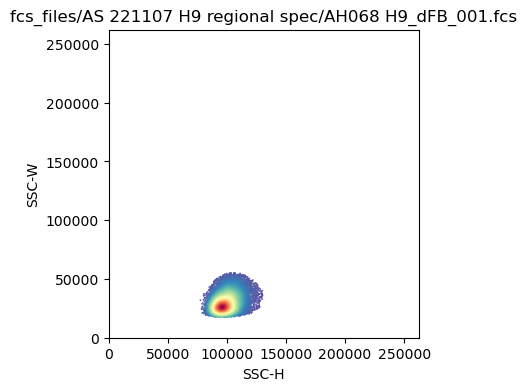

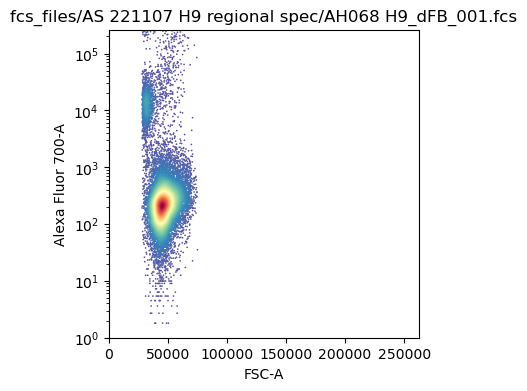

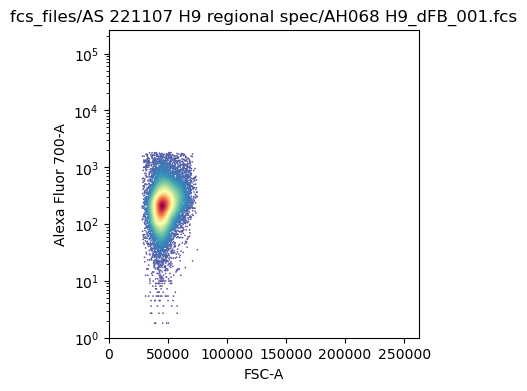

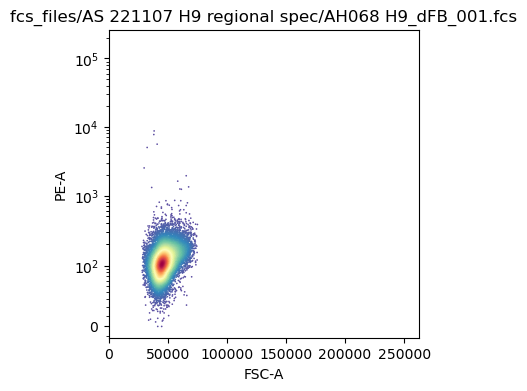

Number of events in gated sample: 14418


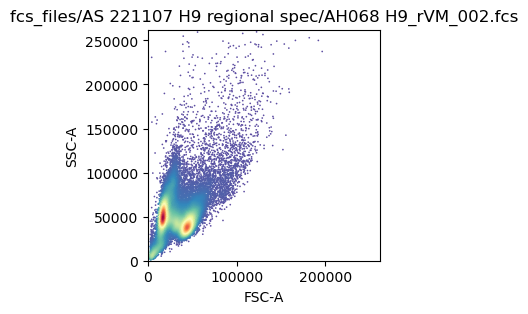

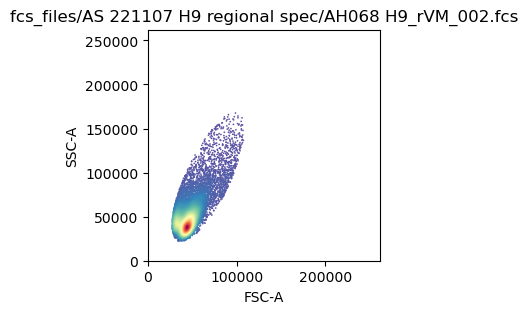

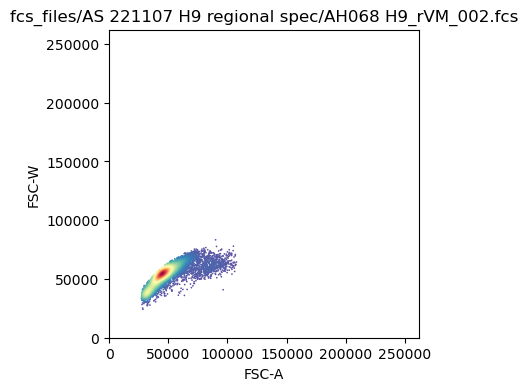

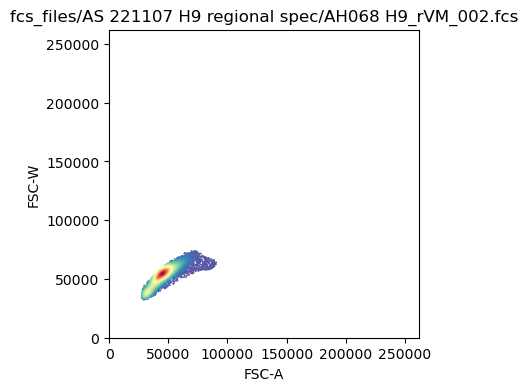

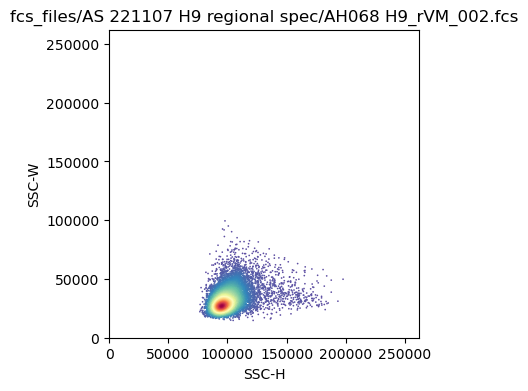

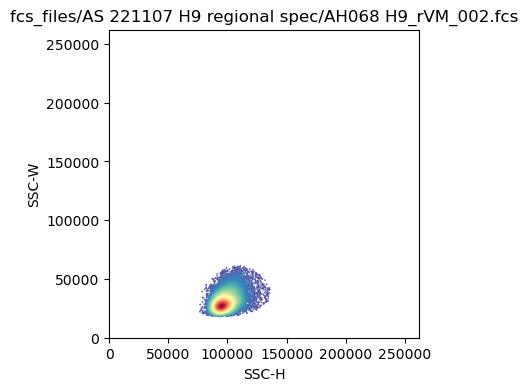

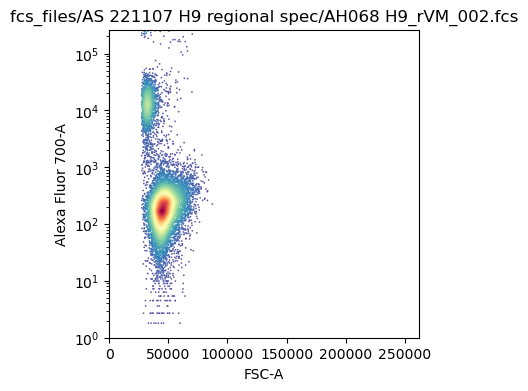

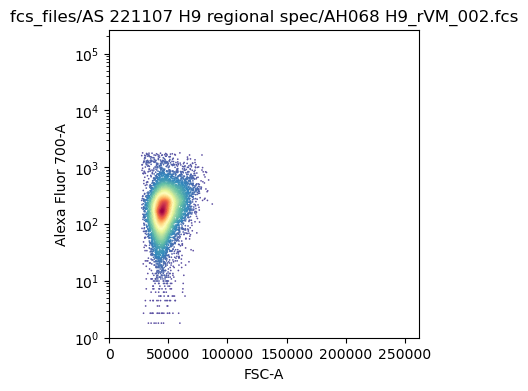

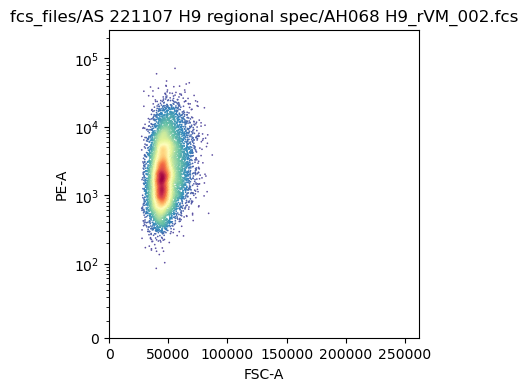

Number of events in gated sample: 8656


In [5]:
#plot with FlowCal.plot.density2d
count = 0
for i, (filename, file) in enumerate(imported_files.items()):
    count += 1
    if count > 3:
        break
    
    #plot the fsc-a vs ssc-a
    plt.figure(figsize=(3, 3)) # make the figure wider
    FlowCal.plot.density2d(file, channels=['FSC-A', 'SSC-A'], mode='scatter', yscale = 'linear', xscale='linear')
    plt.title(filename)
    plt.show()

    #gate the data
    s = FlowCal.gate.ellipse(file, channels=['FSC-A','SSC-A'], 
                             center=(6.8e4, 9.5e4), #center (xy coordinates)
                             a=25000, #width
                             b=80000, #height
                             theta=-25/180.*np.pi) #rotation
    
    #plot the cell gate
    plt.figure(figsize=(3, 3))
    FlowCal.plot.density2d(s, channels=['FSC-A','SSC-A'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #evaluate the results of the gating in fsc-a/fsc-w
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','FSC-W'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #3.(density) fsc-a gate
    s = FlowCal.gate.density2d(s, channels=['FSC-A','FSC-W'], gate_fraction=0.95)

    #plot the singlets-fsc gate
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','FSC-W'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #evaluate the results of the gating in ssc-h/ssc-w
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['SSC-H','SSC-W'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()


    #4. (density) singlets-ssc gate
    s = FlowCal.gate.density2d(s, channels=['SSC-H','SSC-W'], gate_fraction=0.94)
    
    #plot the singlets-ssc gate
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['SSC-H','SSC-W'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #evaluate the results of the gating in draq7
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','Alexa Fluor 700-A'], mode='scatter', xscale='linear', yscale='log')
    plt.title(filename)  # Set the title to the filename
    plt.show()
    
    #5. (threshhold) live gate
    s = FlowCal.gate.high_low(s, channels=['Alexa Fluor 700-A'], high=1800)

    #plot the data 
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','Alexa Fluor 700-A'], mode='scatter', xscale='linear', yscale='log')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #6. gating in markers of interest    
    #6.1 pe
    #plot the data as density plot
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','PE-A'],  mode='scatter', xscale='linear', yscale='logicle')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    print(f"Number of events in gated sample: {s.shape[0]}")

## Calculate cutoffs

In [6]:
# calculate relevant metric for the fmo's of the for each fluorophore and folder
fmo_percentiles = {'PE': [], 'AF488': [], 'PE-Cy7': []}
fmo_means = {'PE-Cy7': [], 'AF488': [], 'PE': []} 
fmo_stds =  {'PE-Cy7': [], 'AF488': [], 'PE': []}

for i, (filename, file) in enumerate(imported_files.items()):
    if 'Unstained' in filename:
        
        #gate
        g1 = FlowCal.gate.ellipse(file, channels=['FSC-A','SSC-A'], 
                                  center=(6.8e4, 9.5e4), #center (xy coordinates)
                                  a=25000, #width
                                  b=80000, #height
                                  theta=-25/180.*np.pi)

        g2 = FlowCal.gate.density2d(g1, channels=['FSC-A','FSC-W'], gate_fraction=0.95)
        g3 = FlowCal.gate.density2d(g2, channels=['SSC-H','SSC-W'], gate_fraction=0.94)
        g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1800)

        #calculate the 99.9th percentile of the fmo's
        if 'PE-vio770' in filename and 'PE-Cy7-A' in g4.channels:
            fmo_percentiles['PE-Cy7'].append(np.percentile(g4[:, 'PE-Cy7-A'], 99.9))
            fmo_means['PE-Cy7'].append(np.mean(g4[:, 'PE-Cy7-A']))
            fmo_stds['PE-Cy7'].append(np.std(g4[:, 'PE-Cy7-A']))
        elif 'AF488' in filename and 'Alexa Fluor 488-A' in g4.channels:
            fmo_percentiles['AF488'].append(np.percentile(g4[:, 'Alexa Fluor 488-A'], 99.9))
            fmo_means['AF488'].append(np.mean(g4[:, 'Alexa Fluor 488-A']))
            fmo_stds['AF488'].append(np.std(g4[:, 'Alexa Fluor 488-A']))
        elif 'PE-A' in g4.channels:
            fmo_percentiles['PE'].append(np.percentile(g4[:, 'PE-A'], 99.9))
            fmo_means['PE'].append(np.mean(g4[:, 'PE-A']))
            fmo_stds['PE'].append(np.std(g4[:, 'PE-A']))

# retrieve the relevant metrics for each fluorophore, separately for each folder and fluorophore
perc_cutoffs = {k: np.mean(v) for k, v in fmo_percentiles.items()}
mean_of_means = {k: np.mean(v) for k, v in fmo_means.items()}
mean_of_stds = {k: np.mean(v) for k, v in fmo_stds.items()}
std_cutoffs_3 = {k: mean + 3*std for k, mean, std in zip(mean_of_means.keys(), mean_of_means.values(), mean_of_stds.values())}
std_cutoffs_8 = {k: mean + 8*std for k, mean, std in zip(mean_of_means.keys(), mean_of_means.values(), mean_of_stds.values())}

print(f"99.9th% cutoffs:\n {perc_cutoffs}")
print(f"Mean+3SD cutoffs:\n {std_cutoffs_3}")
print(f"Mean+8SD cutoffs:\n {std_cutoffs_8}")

99.9th% cutoffs:
 {'PE': 788.9461225586192, 'AF488': nan, 'PE-Cy7': nan}
Mean+3SD cutoffs:
 {'PE-Cy7': nan, 'AF488': nan, 'PE': 389.2693634033203}
Mean+8SD cutoffs:
 {'PE-Cy7': nan, 'AF488': nan, 'PE': 798.2525177001953}


/opt/homebrew/Caskroom/miniforge/base/envs/py_flow_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/homebrew/Caskroom/miniforge/base/envs/py_flow_env/lib/python3.9/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## Plot with cutoffs

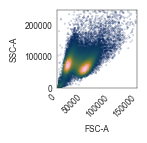

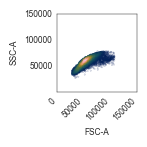

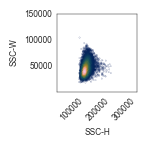

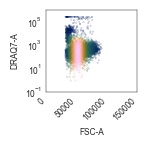

Plotting scatter plot for fcs_files/AS 221107 H9 regional spec/AH068 H9_cVM_003.fcs with gating for PE


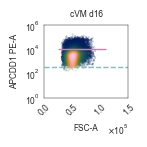

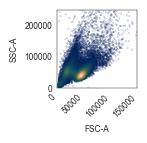

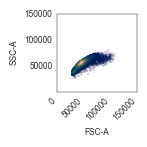

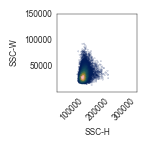

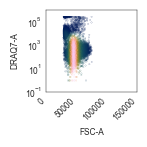

Plotting scatter plot for fcs_files/AS 221107 H9 regional spec/AH068 H9_dFB_001.fcs with gating for PE


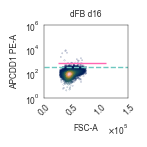

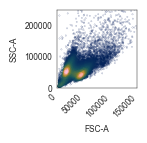

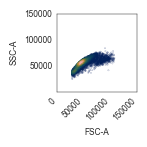

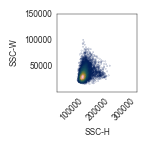

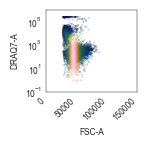

Plotting scatter plot for fcs_files/AS 221107 H9 regional spec/AH068 H9_rVM_002.fcs with gating for PE


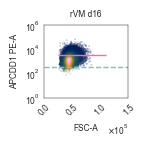

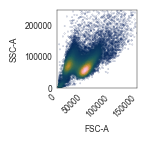

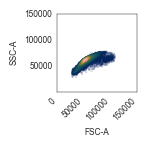

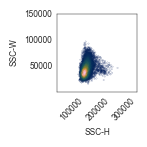

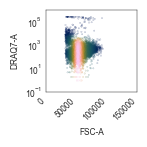

Plotting scatter plot for fcs_files/AS 221107 H9 regional spec/AH069 H9_cVM_006.fcs with gating for PE


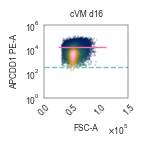

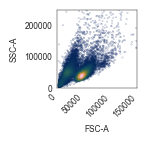

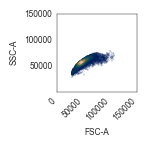

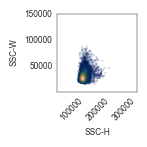

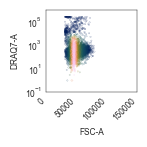

Plotting scatter plot for fcs_files/AS 221107 H9 regional spec/AH069 H9_dFB_004.fcs with gating for PE


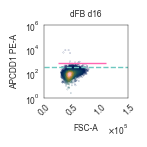

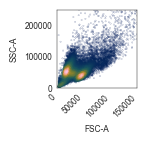

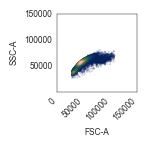

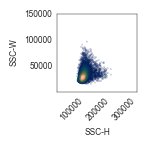

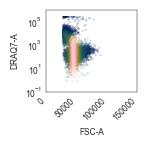

Plotting scatter plot for fcs_files/AS 221107 H9 regional spec/AH069 H9_rVM_005.fcs with gating for PE


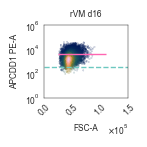

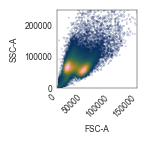

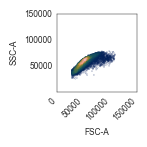

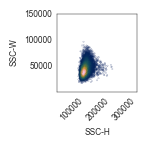

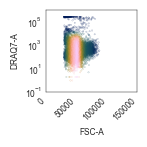

Plotting scatter plot for fcs_files/AS 221107 H9 regional spec/AH071 H9_cVM_009.fcs with gating for PE


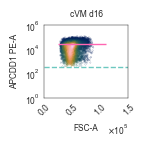

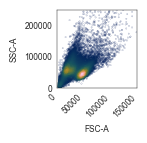

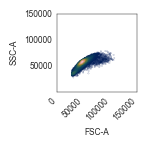

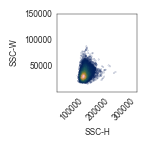

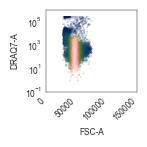

Plotting scatter plot for fcs_files/AS 221107 H9 regional spec/AH071 H9_dFB_007.fcs with gating for PE


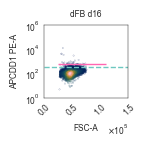

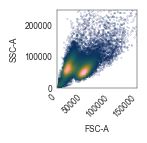

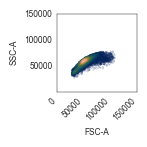

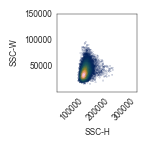

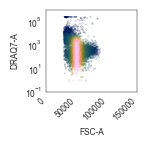

Plotting scatter plot for fcs_files/AS 221107 H9 regional spec/AH071 H9_rVM_008.fcs with gating for PE


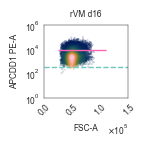

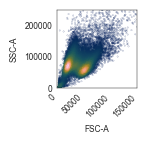

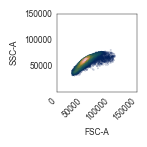

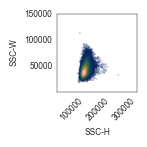

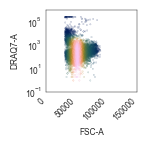

Plotting scatter plot for fcs_files/AS 221107 H9 regional spec/AH072 H9_cVM_012.fcs with gating for PE


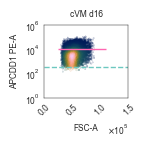

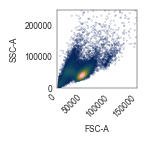

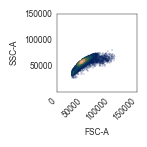

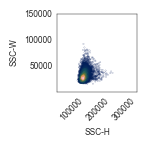

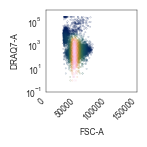

Plotting scatter plot for fcs_files/AS 221107 H9 regional spec/AH072 H9_dFB_010.fcs with gating for PE


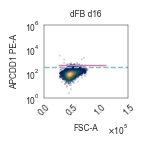

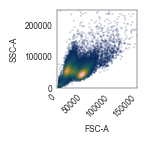

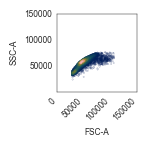

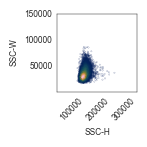

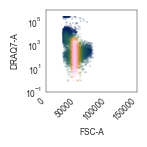

Plotting scatter plot for fcs_files/AS 221107 H9 regional spec/AH072 H9_rVM_011.fcs with gating for PE


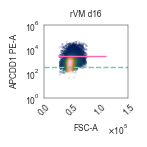

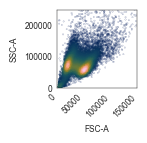

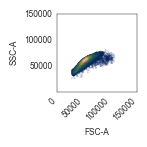

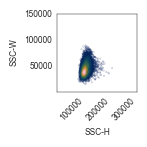

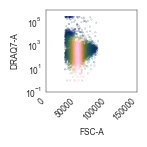

Plotting scatter plot for fcs_files/AS 221107 H9 regional spec/Unstained + D7 controls_cVM_015.fcs with gating for PE


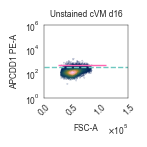

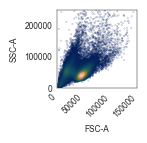

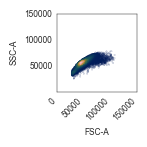

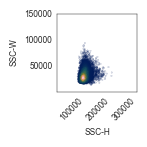

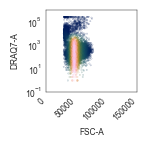

Plotting scatter plot for fcs_files/AS 221107 H9 regional spec/Unstained + D7 controls_dFB_013.fcs with gating for PE


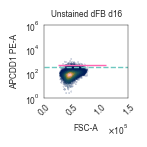

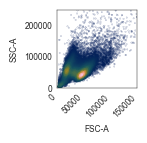

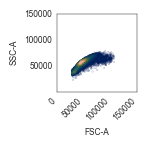

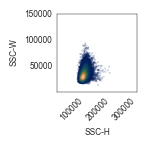

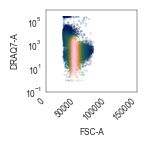

Plotting scatter plot for fcs_files/AS 221107 H9 regional spec/Unstained + D7 controls_rVM_014.fcs with gating for PE


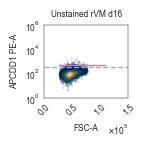

In [7]:
import matplotlib.ticker as ticker

strings_keep = ['Unstained', 
                'dFB', 'rVM', 'cVM']

custom_theme_6pt()

#adjust colormap for density coloring
def modify_colormap_alpha(cmap, alpha=1.0):
    colors = cmap(np.linspace(0, 1, cmap.N))
    colors[:, -1] = alpha  # Set the alpha channel
    return LinearSegmentedColormap.from_list(f"{cmap.name}_opaque", colors)

#load and modify colormap
with open("../../color_palettes/batlow_colors.txt") as f:
    bilbao_colors = [line.strip() for line in f]
bilbao_cmap = LinearSegmentedColormap.from_list("bilbao", bilbao_colors)
opaque_bilbao_cmap = modify_colormap_alpha(bilbao_cmap, alpha=1.0)

#process files
for i, (filename, s) in enumerate(imported_files.items()):

    #clean the filename for the title. keep only strings_keep part of the filename
    title_parts = [string for string in strings_keep if string in filename]
    title = ' '.join(title_parts)

    
    #plot non gated data for FSC-A and SSC-A as a density colored scatter plot as below
    scatter_x = s[:, s.channels.index('FSC-A')].astype('<f8')
    scatter_y = s[:, s.channels.index('SSC-A')].astype('<f8')

    #calculate density
    xy = np.vstack([scatter_x, scatter_y])
    z = gaussian_kde(xy)(xy)
    norm = Normalize(vmin=z.min(), vmax=z.max())
    colors = opaque_bilbao_cmap(norm(z))

    #plot
    plt.figure(figsize=(1.45, 1.45))
    plt.scatter(scatter_x, scatter_y, c=colors, s=0.01, label='Events')
    
    #customize
    plt.xlabel('FSC-A')
    plt.ylabel('SSC-A')
    plt.xlim(0, 1.5e5)
    plt.ylim(0, 2.5e5)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    #save
    output_dir = os.path.dirname(f'facs_plots/{filename}_non_gated.pdf')
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f'facs_plots/{filename}_non_gated.pdf', dpi=100)
    plt.show()
    plt.close()

    #apply gating
    g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], center=(6.8e4, 9.5e4), a=25000, b=80000, theta=-25/180.*np.pi)

    scatter_x = g1[:, g1.channels.index('FSC-A')].astype('<f8')
    scatter_y = g1[:, g1.channels.index('FSC-W')].astype('<f8')

    xy = np.vstack([scatter_x, scatter_y])
    z = gaussian_kde(xy)(xy)
    norm = Normalize(vmin=z.min(), vmax=z.max())
    colors = opaque_bilbao_cmap(norm(z))

    #plot
    plt.figure(figsize=(1.45, 1.45))
    plt.scatter(scatter_x, scatter_y, c=colors, s=0.01, label='Events')

    #customize
    plt.xlabel('FSC-A')
    plt.ylabel('SSC-A')
    plt.xlim(0, 1.5e5)
    plt.ylim(1, 1.5e5)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    #save
    output_dir = os.path.dirname(f'facs_plots/{filename}_gated_fsc_singlets.pdf')
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f'facs_plots/{filename}_gated_fsc_singlets.pdf', dpi=100)
    plt.show()
    plt.close()

    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'], gate_fraction=0.95)

    scatter_x = g2[:, g2.channels.index('SSC-H')].astype('<f8')
    scatter_y = g2[:, g2.channels.index('SSC-W')].astype('<f8')

    xy = np.vstack([scatter_x, scatter_y])
    z = gaussian_kde(xy)(xy)
    norm = Normalize(vmin=z.min(), vmax=z.max())
    colors = opaque_bilbao_cmap(norm(z))

    plt.figure(figsize=(1.45, 1.45))
    plt.scatter(scatter_x, scatter_y, c=colors, s=0.01, label='Events')

    plt.xlabel('SSC-H')
    plt.ylabel('SSC-W')
    plt.xlim(1, 3e5)
    plt.ylim(1, 1.5e5)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    output_dir = os.path.dirname(f'facs_plots/{filename}_gated_ssc_singlets.pdf')
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f'facs_plots/{filename}_gated_ssc_singlets.pdf', dpi=100)
    plt.show()
    plt.close()

    g3 = FlowCal.gate.density2d(g2, channels=['SSC-H', 'SSC-W'], gate_fraction=0.94)

    scatter_x = g3[:, g3.channels.index('FSC-A')].astype('<f8')
    scatter_y = g3[:, g3.channels.index('Alexa Fluor 700-A')].astype('<f8')

    xy = np.vstack([scatter_x, scatter_y])
    z = gaussian_kde(xy)(xy)
    norm = Normalize(vmin=z.min(), vmax=z.max())
    colors = opaque_bilbao_cmap(norm(z))

    plt.figure(figsize=(1.45, 1.45))
    plt.scatter(scatter_x, scatter_y, c=colors, s=0.01, label='Events')

    plt.xlabel('FSC-A')
    plt.ylabel('DRAQ7-A')
    plt.xlim(0, 1.5e5)
    plt.ylim(1e-1, 1e6)
    plt.yscale('log')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    output_dir = os.path.dirname(f'facs_plots/{filename}_gated_af700.pdf')
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f'facs_plots/{filename}_gated_af700.pdf', dpi=100)
    plt.show()
    plt.close()

    g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1800)

    #handle lrtm1 with pe-a
    if 'PE-A' in g4.channels:
        fluorophore_channel = 'PE-A'
        antibody = 'PE'
    else:
        print(f"PE-A not available in {filename}")
        continue

    fluorophore_data = g4[:, g4.channels.index(fluorophore_channel)].astype('<f8')

    #retrieve gating cutoff
    cutoff = std_cutoffs_3.get(antibody, None)
    if cutoff is None:
        print(f"No cutoff available for {antibody}")
        continue

    gated_mask = fluorophore_data > cutoff
    gated_data = fluorophore_data[gated_mask]
    gated_mean = gated_data.mean() if len(gated_data) > 0 else 0

    scatter_x = g4[:, g4.channels.index('FSC-A')].astype('<f8')
    scatter_y = fluorophore_data

    xy = np.vstack([scatter_x, scatter_y])
    z = gaussian_kde(xy)(xy)
    norm = Normalize(vmin=z.min(), vmax=z.max())
    colors = opaque_bilbao_cmap(norm(z))

    print(f"Plotting scatter plot for {filename} with gating for {antibody}")
    plt.figure(figsize=(1.45, 1.45))
    plt.scatter(scatter_x, scatter_y, c=colors, s=0.01, label='Events')

    line_start_cutoff = 0
    line_end_cutoff = 3e5

    line_start_mfi = 0.25e5
    line_end_mfi = 1.1e5

    plt.hlines(y=cutoff, xmin=line_start_cutoff, xmax=line_end_cutoff, colors='#6dc8c0', linestyles='--', label=f"Cutoff: {cutoff:.2f}", linewidth=1)
    plt.hlines(y=gated_mean, xmin=line_start_mfi, xmax=line_end_mfi, colors='#FF66B2', linestyles='-', label=f"Gated Mean: {gated_mean:.2f}", linewidth=1)
    plt.title(f"{title} d16")
    plt.xlabel('FSC-A')
    plt.ylabel(f'APCDD1 PE-A')
    plt.xlim(0, 1.5e5)
    plt.ylim(1, 1e6)
    plt.yscale('log')

    #updated x axis labels
    ax = plt.gca()
    ax.set_xticks([0, 5e4, 1e5, 1.5e5])

    #enable scientific notation
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))  # Force scientific notation
    ax.xaxis.set_major_formatter(formatter)
    plt.xticks(rotation=45, ha='center')
    ax.xaxis.set_tick_params(pad=2)

    plt.tight_layout()

    #save
    output_dir = os.path.dirname(f'facs_plots/{filename}_gated_{antibody}.pdf')
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f'facs_plots/{filename}_gated_{antibody}_with_density.pdf', dpi=100)
    plt.show()
    plt.close

## Process the data

In [8]:
#define gating function
def plot_and_gate(g, channels, title, mode='scatter', xscale='linear', yscale='linear', gate=None, cutoff=None, inverse=False):
    if gate and cutoff is not None:
        print(f"Applying gate on {channels[1]} with cutoff {cutoff} (inverse={inverse})")
        initial_count = g.shape[0]
        if inverse:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], low=cutoff)
        else:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], high=cutoff)
        final_count = g.shape[0]
        print(f"Initial count: {initial_count}, Final count after gating: {final_count}, Percentage retained: {round((final_count / initial_count) * 100, 2)}%")
    return g

def plot_staggered_histograms(data, title, delta_y=0.5):
    plt.figure(figsize=(10, 6))
    y_ticks = []
    y_labels = []
    for i, (label, (g, channel)) in enumerate(data.items()):
        # Extract the data for the specified channel
        channel_data = g[:, g.channels.index(channel)]
        # Compute the histogram
        hist, bins = np.histogram(channel_data, bins=50)
        # Compute the baseline and the y-change
        baseline = min(hist)
        y_change = delta_y * i - baseline
        # Apply the y-change to the histogram
        hist = hist + y_change
        # Plot the histogram
        plt.fill_between(bins[:-1], hist, np.ones_like(hist) * delta_y * i, alpha=0.5, label=f"{label} - {channel}")
        y_ticks.append(delta_y * i)
        y_labels.append(label)
    plt.title(title)
    plt.xlabel('Fluorescence Intensity')
    plt.ylabel('Sample')
    plt.yticks(y_ticks, y_labels)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

#channel to cutoff key mapping
channel_to_cutoff_key = {
    'PE-A': 'PE',
    'PE-Cy7-A': 'PE-Cy7',
    'Alexa Fluor 488-A': 'AF488'
}

data = []

#plot and gate the data
for i, (filename, file) in enumerate(imported_files.items()):
    print(f'Processing... {filename}')

    plot_and_gate(file, ['FSC-A','SSC-A'], filename + '(before gating)')
    g1 = FlowCal.gate.ellipse(file, channels=['FSC-A','SSC-A'], 
                              center=(6.8e4, 9.5e4), a=25000, b=80000, theta=-25/180.*np.pi)
    plot_and_gate(g1, ['FSC-A','SSC-A'], filename + '(after gating)')
    plot_and_gate(g1, ['FSC-A','FSC-W'], filename + '(before gating)')
    if g1.shape[0] <= 1:
        print(f"Skipping sample {filename} as it has <2 events after fsc-singlets gating.")
        continue
    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A','FSC-W'], gate_fraction=0.95)
    plot_and_gate(g2, ['FSC-A','FSC-W'], filename + '(after gating)')
    plot_and_gate(g2, ['SSC-H','SSC-W'], filename + '(before gating)')
    g3 = FlowCal.gate.density2d(g2, channels=['SSC-H','SSC-W'], gate_fraction=0.94)
    plot_and_gate(g3, ['SSC-H','SSC-W'], filename + '(after gating)')
    plot_and_gate(g3, ['FSC-A','Alexa Fluor 700-A'], filename + '(before gating)', yscale='log')
    g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1800)
    plot_and_gate(g4, ['FSC-A','Alexa Fluor 700-A'], filename + '(after gating)', yscale='log')
    live_gate_events = g4.shape[0]

    #process fluorophores separately
    pe_cy7_gate_events = pe_gate_events = af488_gate_events = 0
    means_3sd = {}

    if 'PE-A' in g4.channels:
        g5 = FlowCal.gate.high_low(g4, channels=['PE-A'], low=perc_cutoffs['PE'])
        g5_gate_events = g5.shape[0]

        g5_3sd = FlowCal.gate.high_low(g4, channels=['PE-A'], low=std_cutoffs_3['PE'])
        means_3sd = np.mean(g5_3sd[:, 'PE-A'])
        g5_3sd_gate_events = g5_3sd.shape[0]

        g5_8sd = FlowCal.gate.high_low(g4, channels=['PE-A'], low=std_cutoffs_8['PE'])
        means_9sd = np.mean(g5_8sd[:, 'PE-A'])
        pe_gate_events = g5_8sd.shape[0]


    else:
        print(f"Skipping {filename} as it does not contain PE-A.")
        continue

    data.append({
        'filename': filename,
        'live_cells_gate_events': live_gate_events,
        'percentile_gate_events': g5_gate_events,
        '3sd_mfi': means_3sd,
        '3sd_gate_events': g5_3sd_gate_events,
        '8sd_mfi': means_9sd,
        '8sd_gate_events': pe_gate_events
    })

#convert to df
df = pd.DataFrame(data)

#save and inspect
df.to_csv('output/regional_spec_h9 py.csv', index=False)
df.head()

Processing... fcs_files/AS 221107 H9 regional spec/AH068 H9_cVM_003.fcs


Processing... fcs_files/AS 221107 H9 regional spec/AH068 H9_dFB_001.fcs


Processing... fcs_files/AS 221107 H9 regional spec/AH068 H9_rVM_002.fcs


Processing... fcs_files/AS 221107 H9 regional spec/AH069 H9_cVM_006.fcs


Processing... fcs_files/AS 221107 H9 regional spec/AH069 H9_dFB_004.fcs


...

Processing... fcs_files/AS 221107 H9 regional spec/AH072 H9_rVM_011.fcs


Processing... fcs_files/AS 221107 H9 regional spec/Unstained + D7 controls_cVM_015.fcs


Processing... fcs_files/AS 221107 H9 regional spec/Unstained + D7 controls_dFB_013.fcs


Processing... fcs_files/AS 221107 H9 regional spec/Unstained + D7 controls_rVM_014.fcs


,filename,live_cells_gate_events,percentile_gate_events,3sd_mfi,3sd_gate_events,8sd_mfi,8sd_gate_events
0,fcs_files/AS 221107 H9 regional spec/AH068 H9_...,11424,10948,10604.259766,11374,11007.924805,10932
1,fcs_files/AS 221107 H9 regional spec/AH068 H9_...,14418,15,769.042908,118,2771.875244,15
2,fcs_files/AS 221107 H9 regional spec/AH068 H9_...,8656,7469,3575.338867,8479,3985.582275,7447
3,fcs_files/AS 221107 H9 regional spec/AH069 H9_...,10205,10037,16776.410156,10187,17031.013672,10029
4,fcs_files/AS 221107 H9 regional spec/AH069 H9_...,9149,8,754.254517,109,4160.638672,8


In [9]:
df = pd.read_csv('output/regional_spec_h9 py.csv')

df['date_analyzed'] = '2022-11-07'

#remove the folder path from the filename
df['filename'] = df['filename'].str.replace('fcs_files/AS 221107 H9 regional spec/', '')

#if 'unstained' in filename, set the kind to 'fmo', otherwise set to 'sample'
df['kind'] = np.where(df['filename'].str.contains('Unstained'), 'fmo', 'sample')

#calculate %+
per_pos_cols = ['percentile_gate_events', '3sd_gate_events', '8sd_gate_events']

for col in per_pos_cols:
    df[f'{col}_per_pos'] = round(100 * (df[col] / df['live_cells_gate_events']), 2)

#extract the region from the filename
region_strings = ['cVM', 'dFB', 'rVM']
for region in region_strings: 
    df.loc[df['filename'].str.contains(region), 'region'] = region

#extract the batch from the filename
batch_strings = ['AH068', 'AH069', 'AH071', 'AH072']
for batch in batch_strings:
    df.loc[df['filename'].str.contains(batch), 'batch'] = batch

df.loc[~df['filename'].str.contains('|'.join(batch_strings)), 'batch'] = 'mix'

#extract the antibody from the kind
def sample_type(x):
    if 'sample' in x:
        return 'APCDD1'
    else:
        return 'unstained'

df['antibody'] = df['kind'].apply(sample_type)

#remove and rearrange cols
df.drop(['filename', 'live_cells_gate_events', 'percentile_gate_events', '3sd_gate_events', '8sd_gate_events'], axis=1, inplace=True)

#remove the string 'gate_events' from the column names
df.columns = df.columns.str.replace('_gate_events', '')

df=df[['antibody', 'batch', 'region', 'kind', 'date_analyzed', '3sd_mfi', 'percentile_per_pos', '3sd_per_pos', '8sd_per_pos', '8sd_mfi']]

#save the df
df.to_csv('output/regional_spec_h9 py clean.csv', index=False)
df.head()

,antibody,batch,region,kind,date_analyzed,3sd_mfi,percentile_per_pos,3sd_per_pos,8sd_per_pos,8sd_mfi
0,APCDD1,AH068,cVM,sample,2022-11-07,10604.2600,95.83,99.56,95.69,11007.9250
1,APCDD1,AH068,dFB,sample,2022-11-07,769.0429,0.10,0.82,0.10,2771.8752
2,APCDD1,AH068,rVM,sample,2022-11-07,3575.3389,86.29,97.96,86.03,3985.5823
3,APCDD1,AH069,cVM,sample,2022-11-07,16776.4100,98.35,99.82,98.28,17031.0140
4,APCDD1,AH069,dFB,sample,2022-11-07,754.2545,0.09,1.19,0.09,4160.6387


In [10]:
h9=pd.read_csv('output/regional_spec_h9 py clean.csv')
h9_apcdd1=h9[h9['antibody'] == 'APCDD1']
h9.head()

,antibody,batch,region,kind,date_analyzed,3sd_mfi,percentile_per_pos,3sd_per_pos,8sd_per_pos,8sd_mfi
0,APCDD1,AH068,cVM,sample,2022-11-07,10604.2600,95.83,99.56,95.69,11007.9250
1,APCDD1,AH068,dFB,sample,2022-11-07,769.0429,0.10,0.82,0.10,2771.8752
2,APCDD1,AH068,rVM,sample,2022-11-07,3575.3389,86.29,97.96,86.03,3985.5823
3,APCDD1,AH069,cVM,sample,2022-11-07,16776.4100,98.35,99.82,98.28,17031.0140
4,APCDD1,AH069,dFB,sample,2022-11-07,754.2545,0.09,1.19,0.09,4160.6387


In [11]:
#set region levels
region_lvls = ['dFB', 'rVM', 'cVM']
cat_type = CategoricalDtype(categories=region_lvls, ordered=True)
h9_apcdd1['region'] = h9_apcdd1['region'].astype(cat_type)
h9_apcdd1['region'].unique()

/var/folders/9p/d9yjsp0n08d5t86rw98cmx0h0000gn/T/ipykernel_14928/2457794486.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  h9_apcdd1['region'] = h9_apcdd1['region'].astype(cat_type)


['cVM', 'dFB', 'rVM']
Categories (3, object): ['dFB' < 'rVM' < 'cVM']

## Plot the processed data

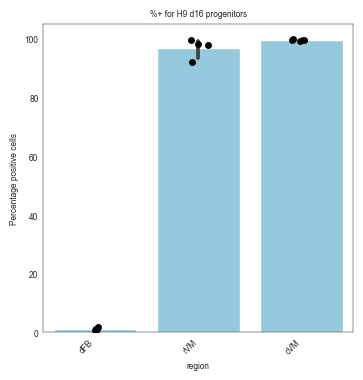

In [12]:
#plot the data as a barplot with dots with antibodies on the x-axis and the percentage positive on the y-axis
custom_theme_6pt()
plt.figure(figsize=(4, 4))
sns.barplot(data=h9_apcdd1, x='region', y='3sd_per_pos', color='skyblue')
sns.stripplot(data=h9_apcdd1, x='region', y='3sd_per_pos', color='black', size=5, jitter=True)
plt.title('%+ for H9 d16 progenitors')
plt.ylabel('Percentage positive cells')
plt.xticks(rotation=45, ha='right')
plt.show()

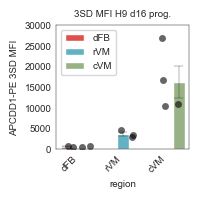

In [13]:
#remove the batch == "AH071" for region == "rVM"
h9_apcdd1 = h9_apcdd1[~((h9_apcdd1['region'] == 'rVM') & (h9_apcdd1['batch'] == 'AH071'))]

region_pal = ["#F63B32", "#52BCD4", "#95BB7E"]

custom_theme_7pt()

plt.figure(figsize=(2, 2))
sns.barplot(data=h9_apcdd1, x='region', y='3sd_mfi', 
            hue='region', palette=region_pal,
            errorbar='se', errwidth=0.2, capsize=0.2, errcolor='black'
            )
sns.stripplot(data=h9_apcdd1, x='region', y='3sd_mfi', color='black', size=5, jitter=0.3, alpha=0.6)
plt.title('3SD MFI H9 d16 prog.')
plt.ylabel('APCDD1-PE 3SD MFI')
plt.xticks(rotation=45, ha='right')
plt.ylim(0,3e4)
plt.tight_layout()
plt.savefig('figs/regional spec h9.pdf', dpi=300)
plt.show()

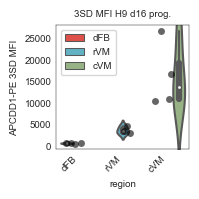

In [14]:
custom_theme_7pt()

plt.figure(figsize=(2, 2))
sns.violinplot(data=h9_apcdd1, x='region', y='3sd_mfi', 
            hue='region', palette=region_pal,
            #errorbar='se', errwidth=0.2, capsize=0.2, errcolor='black'
            )
sns.stripplot(data=h9_apcdd1, x='region', y='3sd_mfi', color='black', size=5, jitter=0.3, alpha=0.6)
plt.title('3SD MFI H9 d16 prog.')
plt.ylabel('APCDD1-PE 3SD MFI')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
#plt.savefig('figs/regional spec h9.pdf', dpi=300)
plt.show()